In [125]:
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

# I - Chargement et traitement des données de l'API de TMDB

La première étape consiste à charger les données de TMDB grâce à leur API

In [2]:
ids= td.get_movie_ids_list(50, headers=td.headers)
df=td.get_movies_info(ids,headers=td.headers)
df.head(3)

getting movie ids


100%|██████████| 50/50 [00:34<00:00,  1.45it/s]


getting movie info


100%|██████████| 1000/1000 [03:45<00:00,  4.42it/s]


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,/bGksau9GGu0uJ8DJQ8DYc9JW5LM.jpg,None,13000000,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",,77338,tt1675434,[FR],fr,...,Released,Sometimes you have to reach into someone else'...,The Intouchables,False,8.276,17218,NaN,NaN,NaN,NaN
1,False,/6n53UI4mX9QMfe2S0Pgt8mGebY1.jpg,None,10000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",https://www.miramax.com/movie/amelie/,194,tt0211915,[FR],fr,...,Released,She’ll change your life.,Amélie,False,7.914,11500,NaN,NaN,NaN,NaN
2,False,/uuyC8vih50lyRKjxQ5FWjCF6hGN.jpg,None,4300000,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",,152584,tt2278871,[FR],fr,...,Released,,Blue Is the Warmest Color,False,7.100,4557,NaN,NaN,NaN,NaN


Telles quelles les données sont nombreuses et pas toutes nécessaires. Pour la lisibilité on élimine certaines colones, et traite certaines données. Par ailleurs, on construit de variables "overview_count" et "title_count" qui comptent le nombre de caractère de "overview" et de "title".

In [51]:
df1=td.drop_useless_info(df)
df1=td.keep_main_genre(df1)
df1=td.full_poster_path(df1)
df1=td.count_words(df1)
df1.head

<bound method NDFrame.head of        budget      id                                           overview  \
0    13000000   77338  A true story of two men who should never have ...   
1    10000000     194  At a tiny Parisian café, the adorable yet pain...   
2     4300000  152584  Adèle's life is changed when she meets Emma, a...   
3     2600000     406  After a chaotic night of rioting in a marginal...   
4    58500000    2899  The Egyptian Queen Cleopatra bets against the ...   
..        ...     ...                                                ...   
995         0  589985  Vali and Mina are two sisters who are polar op...   
996  30000000   47904  After losing their family home in Algeria in t...   
997         0   42044  Director Claude Lanzmann spent 11 years on thi...   
998         0   10401  It's night on a Paris bridge. A girl leans ove...   
999         0    2455  Claude Massoulier is murdered while hunting at...   

     popularity release_date    revenue  runtime  \
0    

# II - Analyse descriptive des données

# III - Prédiction des notes et du genre d'un film

## B - Prédire le genre grâce à des Forêts Aléatoires

On s'intéresse maintenant au genre d'un film, et on cherche à le prédire gr6ace à nos données. On va utiliser pour cela un modèle classique de Machine Learning: les forêts aléatoires. 

In [17]:
dfrf=df1[df1['main_genre_id'].isin([28,18, 35])]

X=dfrf.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=dfrf['main_genre_id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Création et entraînement du modèle
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 4. Prédictions
y_pred = model.predict(X_test)

# 5. Évaluation
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

          18       0.59      0.70      0.64        50
          28       0.00      0.00      0.00        11
          35       0.77      0.77      0.77        87

    accuracy                           0.69       148
   macro avg       0.45      0.49      0.47       148
weighted avg       0.65      0.69      0.67       148



In [18]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance)

vote_average      0.221689
runtime           0.166712
popularity        0.146136
overview_count    0.123053
vote_count        0.118895
title_count       0.096569
revenue           0.074177
budget            0.052769
dtype: float64



Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.33      0.10      0.15        10
      Adventure       0.00      0.00      0.00        10
      Animation       0.00      0.00      0.00         5
         Comedy       0.53      0.76      0.62        86
          Crime       0.50      0.12      0.20         8
    Documentary       0.00      0.00      0.00         2
          Drama       0.40      0.59      0.48        49
         Family       0.00      0.00      0.00         2
        Fantasy       0.00      0.00      0.00         2
        History       0.00      0.00      0.00         2
         Horror       0.00      0.00      0.00         3
          Music       0.00      0.00      0.00         3
        Mystery       0.00      0.00      0.00         4
        Romance       0.00      0.00      0.00         8
Science Fiction       0.00      0.00      0.00         0
       Thriller       0.00      0.00      0.00         4
 

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.12/site-packages/sklearn/me

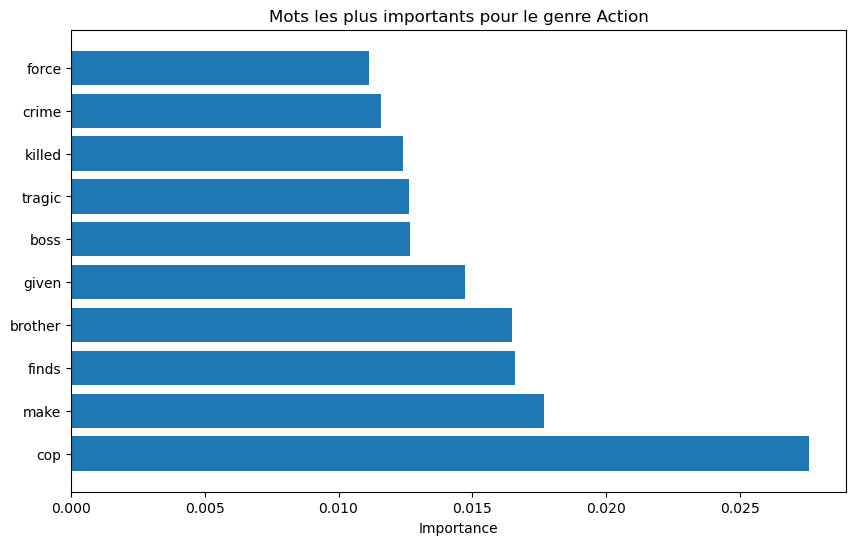

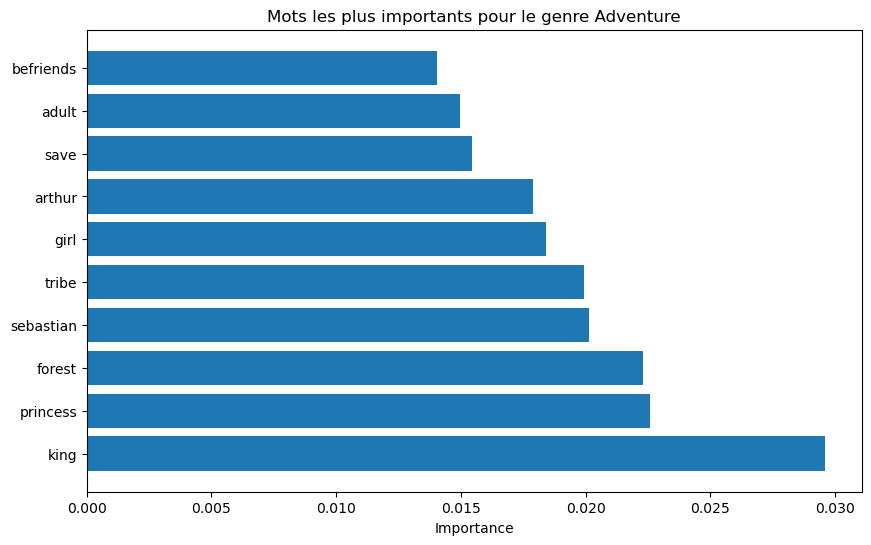

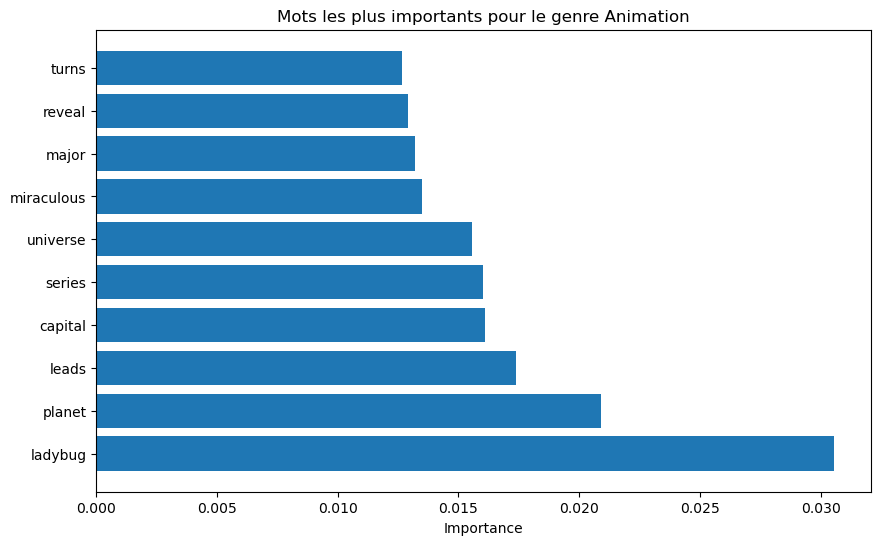

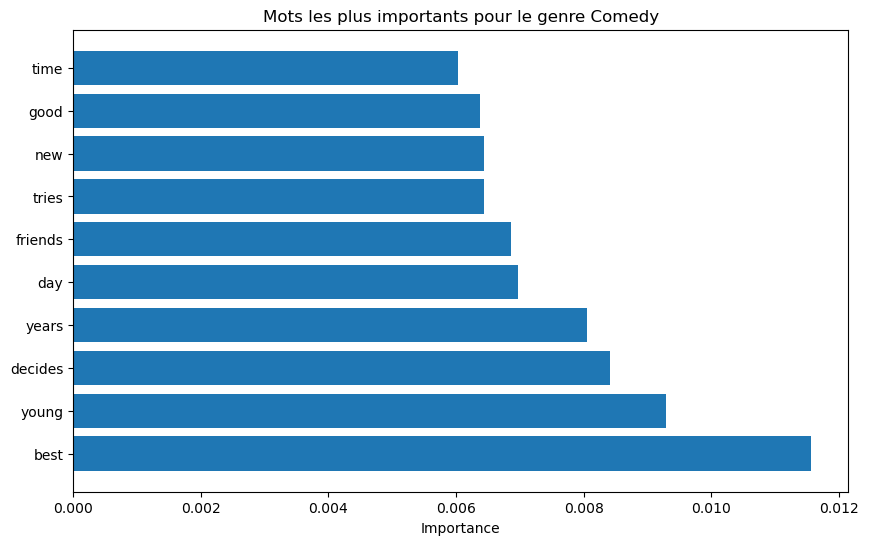

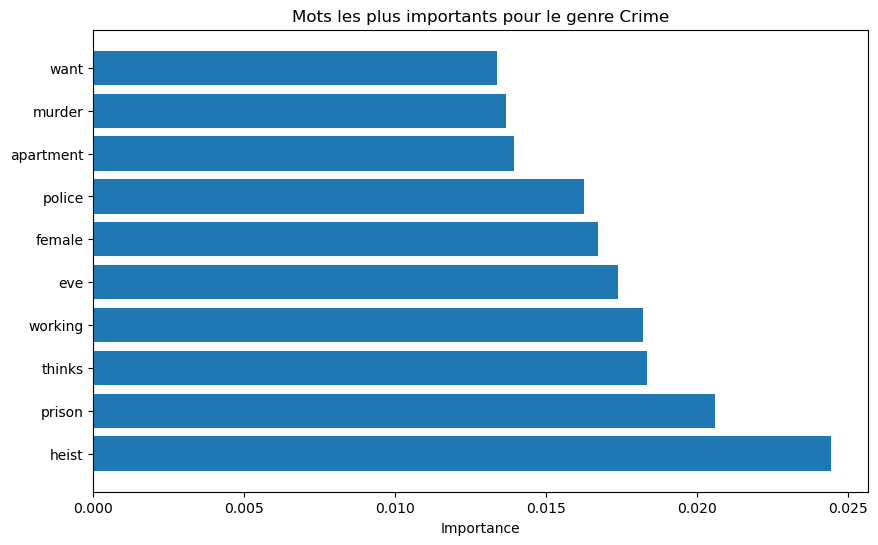

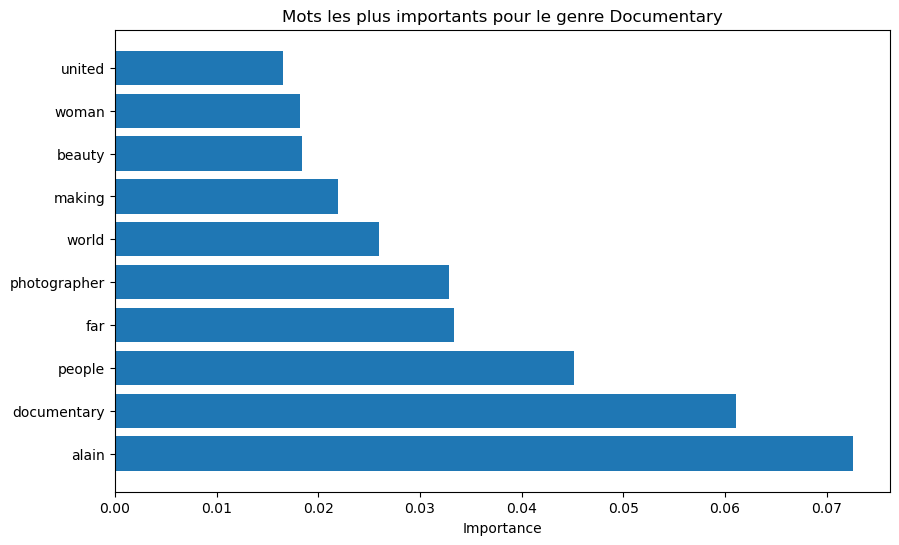

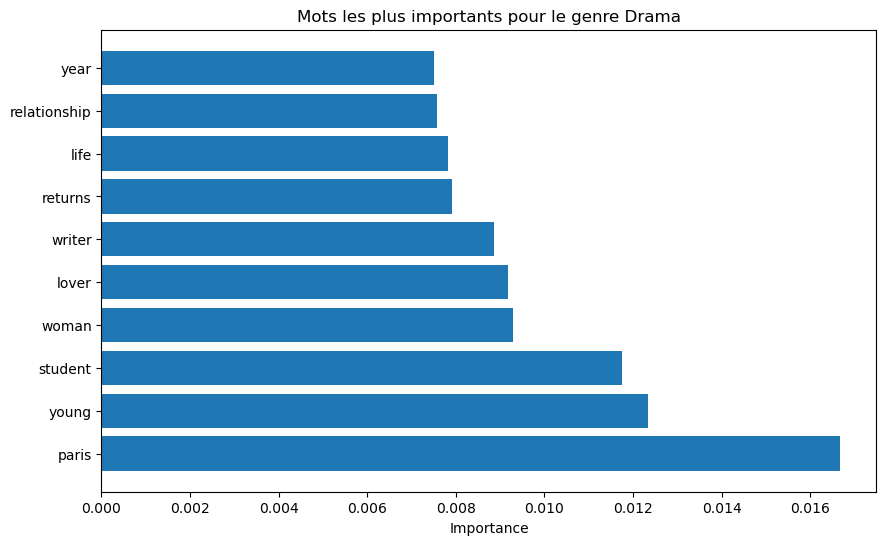

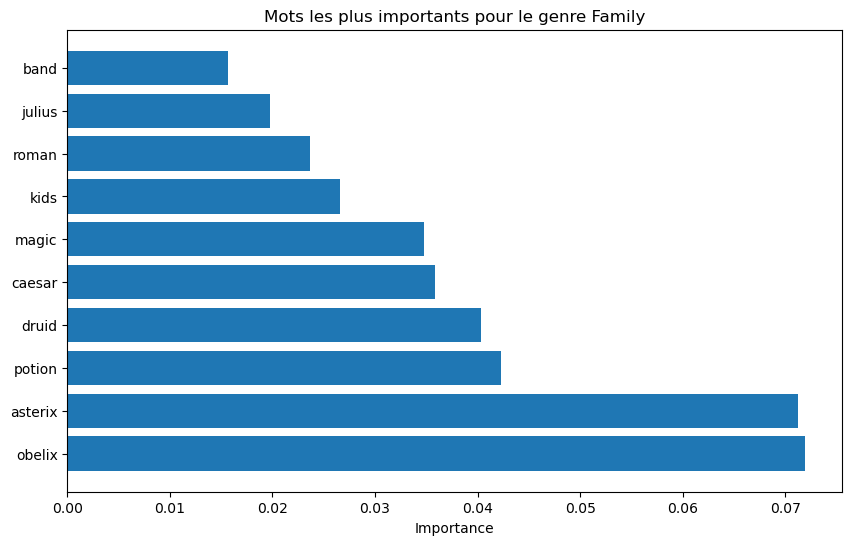

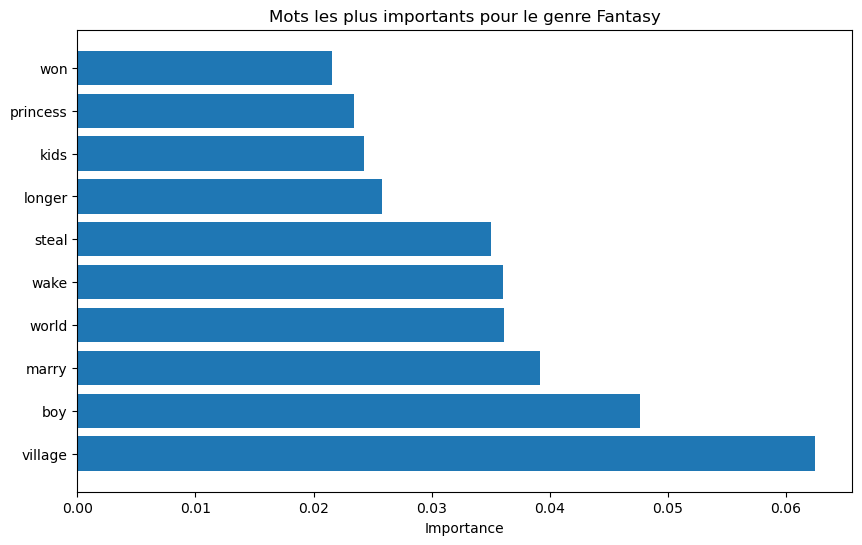

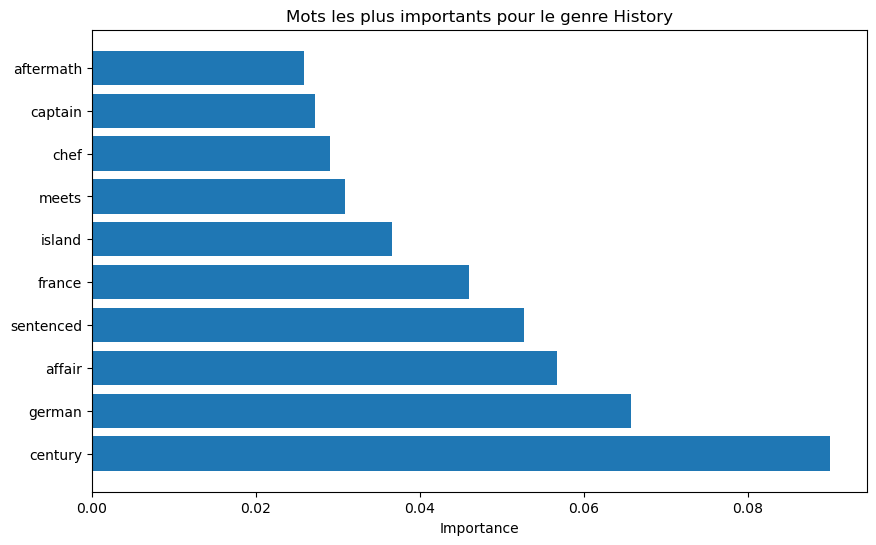

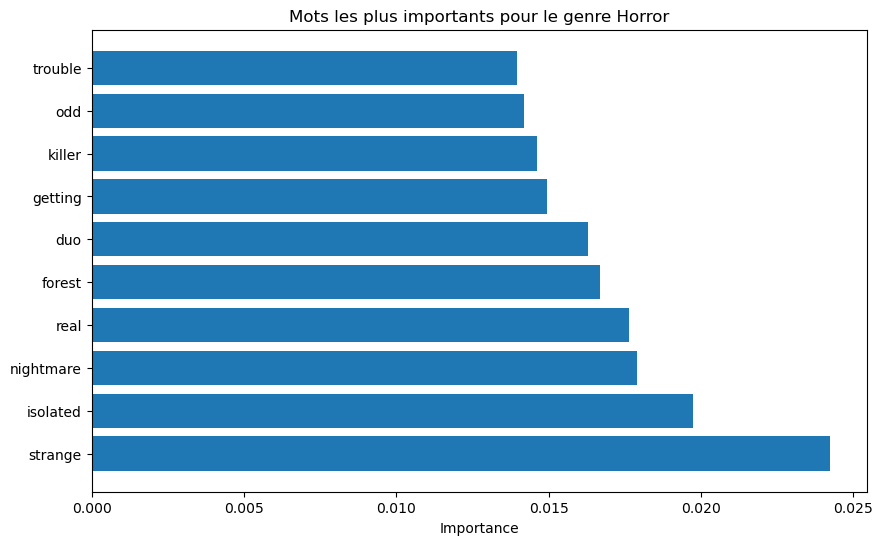

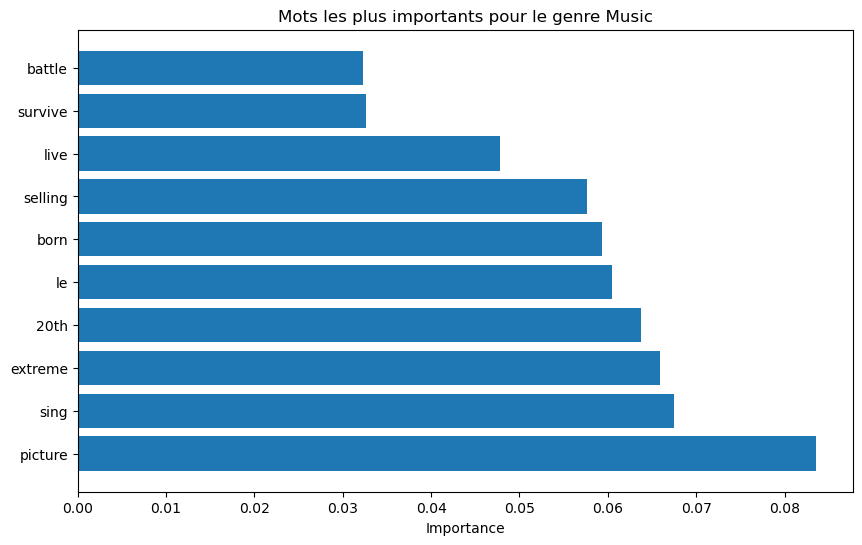

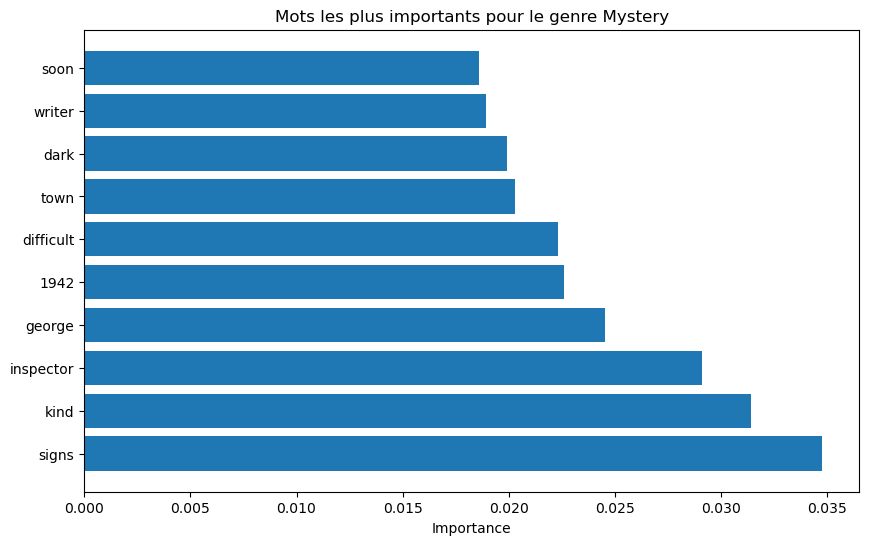

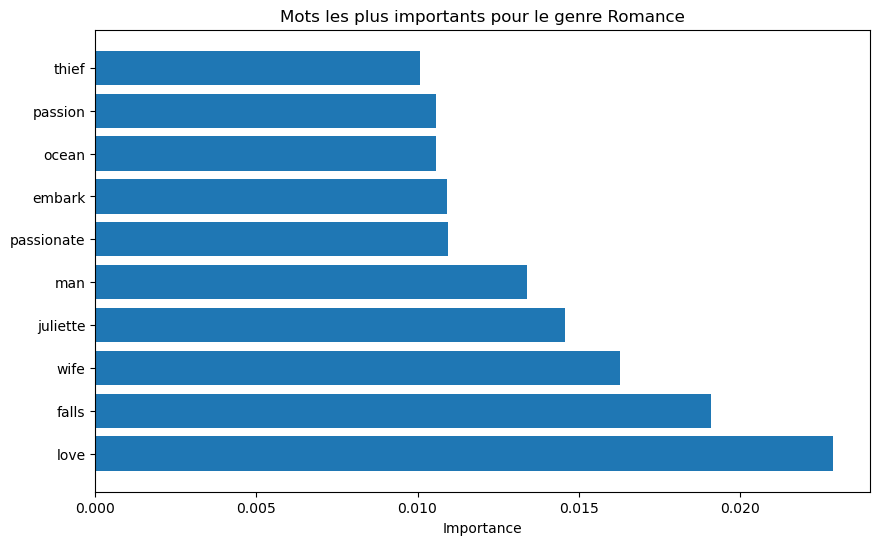

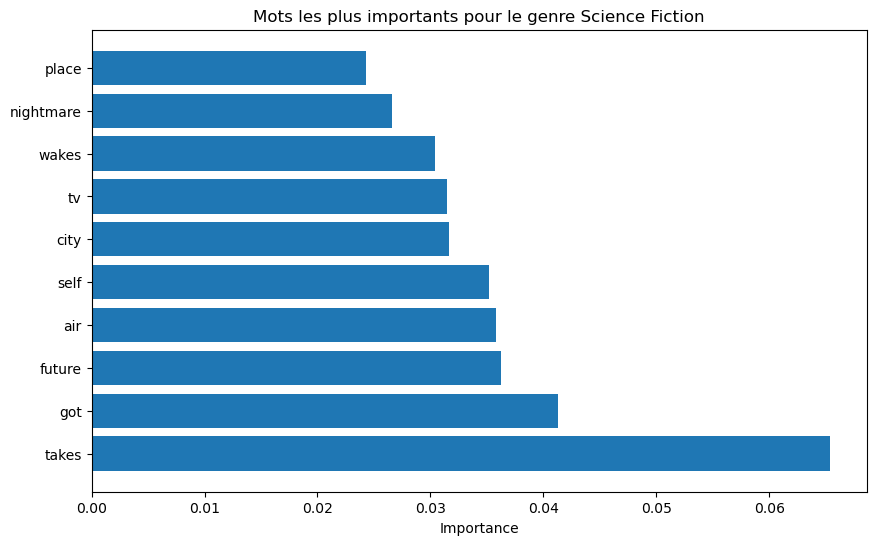

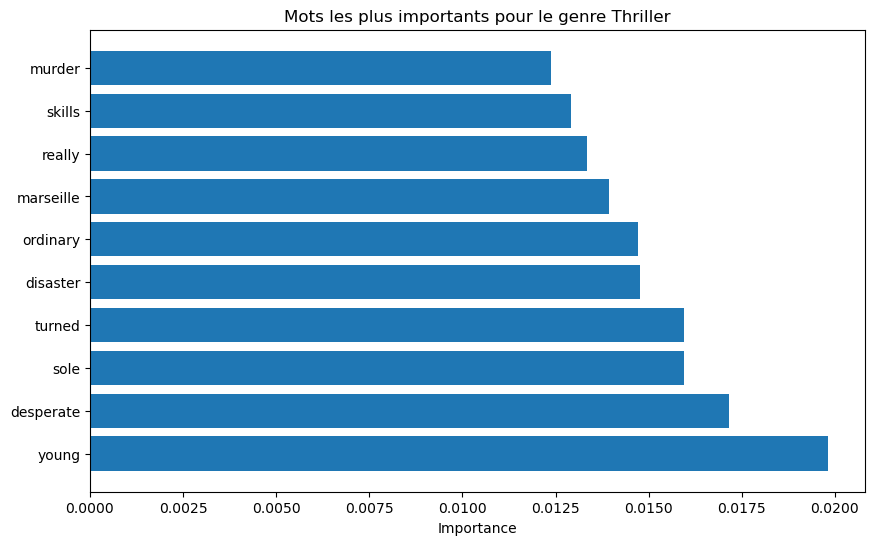

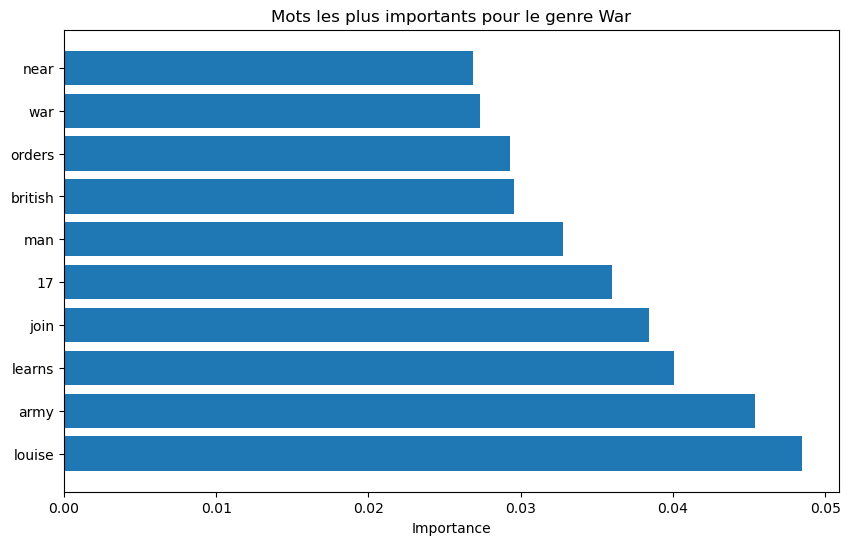

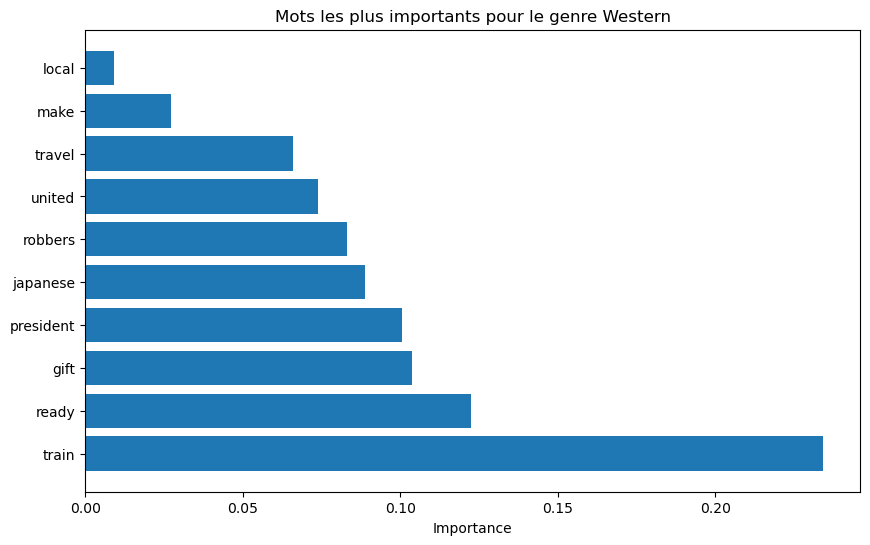

In [141]:


label_encoder = LabelEncoder()
df1['genre_encoded'] = label_encoder.fit_transform(df1['main_genre_name'])

# Séparer les données en caractéristiques (X) et labels (y)
X = df1['overview']
y = df1['genre_encoded']

# Diviser les données en un ensemble d'entraînement et un ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer le TfidfVectorizer avec des paramètres plus stricts
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, min_df=2, max_df=0.95)

# Appliquer le vectoriseur aux données d'entraînement
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Créer un modèle One-vs-Rest avec RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Appliquer One-vs-Rest pour chaque genre
ovr_model = OneVsRestClassifier(rf_model)
ovr_model.fit(X_train_tfidf, y_train)

# Vérifier la précision du modèle sur les données de test
accuracy = ovr_model.score(X_test_tfidf, y_test)
y_pred = ovr_model.predict(X_test_tfidf)

target_labels = label_encoder.classes_
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=target_labels, labels=np.arange(len(target_labels))))


print(f"Précision du modèle : {accuracy:.4f}")

# Optionnel : Visualiser les mots les plus importants pour un genre spécifique
def plot_important_words_for_genre(importances, feature_names, genre_index, top_n=10):
    sorted_indices = np.argsort(importances)[::-1][:top_n]
    words = [feature_names[i] for i in sorted_indices]
    scores = importances[sorted_indices]
    
    plt.figure(figsize=(10, 6))
    plt.barh(words, scores)
    plt.xlabel('Importance')
    plt.title(f'Mots les plus importants pour le genre {label_encoder.classes_[genre_index]}')
    plt.show()

for i in range(len(y.unique())):
    # Exemple : Visualiser les mots les plus importants pour le genre 0 (Drama)
    plot_important_words_for_genre(ovr_model.estimators_[i].feature_importances_, 
                                vectorizer.get_feature_names_out(), genre_index=i)